# Árbol de descisión y Bosque aletorio

Ismael Quesada Salas

## Parte 1: Arbol de Decisión (Decision Tree)

In [1]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

In [ ]:
mydata = load_iris()

X = mydata.data # data de entrada
y = mydata.target # data de salida

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [3]:
mydata.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [4]:
mydata.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
# Generamos una triple particion de los datos: entrenamiento, validación y prueba (60-20-20)
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=.2, shuffle=True, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=.25, shuffle=True, random_state=1)

print('Tamaño del conjunto de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de validación:', X_val.shape)
print('Tamaño del conjunto de prueba', X_test.shape)

Tamaño del conjunto de entrenamiento: (90, 4)
Tamaño del conjunto de validación: (30, 4)
Tamaño del conjunto de prueba (30, 4)


C:\Users\quesa\AppData\Local\Temp\ipykernel_17364\3582939746.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(X, labels=mydata.feature_names)


{'whiskers': [<matplotlib.lines.Line2D at 0x1f485e274d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1f485e27750>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f485d0f390>,
 'medians': [<matplotlib.lines.Line2D at 0x1f485e279d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x1f485e27b10>,
 'means': []}

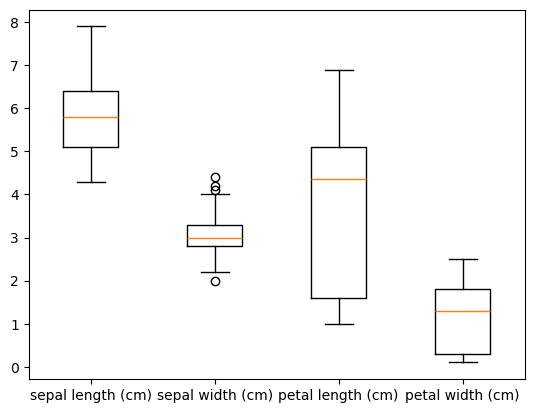

In [6]:
plt.boxplot(X, labels=mydata.feature_names)

In [7]:
## Generemos un arbol de decision 

modelDT = DecisionTreeClassifier() # Inicializamos con los hiperparametros determinados
clf = modelDT.fit(X_train, y_train) # Entrenamos el modelo con los datos de entrenamiento

# observemos el desempeño
print("Exactitud en el conjunto de entrenamiento: ", clf.score(X_train, y_train))

Exactitud en el conjunto de entrenamiento:  1.0


In [8]:
predicciones = clf.predict(X_val) # Realizamos predicciones sobre el conjunto de validación
print("Exactitud en el conjunto de validación: ", clf.score(X_val, y_val))

Exactitud en el conjunto de validación:  0.9666666666666667


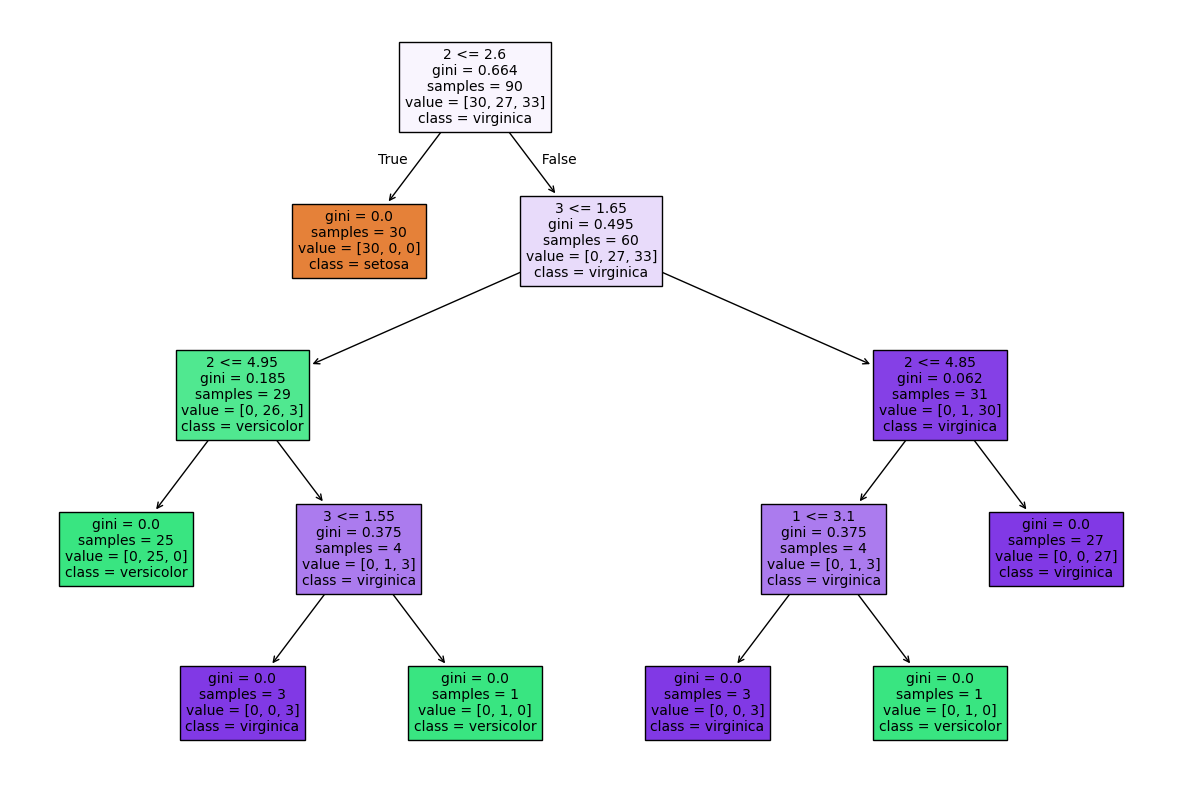

In [9]:
# Para realizar un grafo de Decision Tree
from sklearn import tree
# 1. Configurar el tamaño de la imagen
plt.figure(figsize=(15, 10))
# 2. Dibujar el árbol directamente
tree.plot_tree(decision_tree=clf,
               max_depth=None,
               feature_names=list(pd.DataFrame(X_train).columns.astype(str)),
               class_names=[str(c) for c in mydata.target_names],
               filled=True,
               proportion=False,
               fontsize=10)
# 3. Mostrar la imagen en Jupyter
plt.show()

## Parte 2 : Random Forest (Bosque aletorio)

In [10]:
from sklearn.ensemble import RandomForestClassifier
import sklearn.datasets

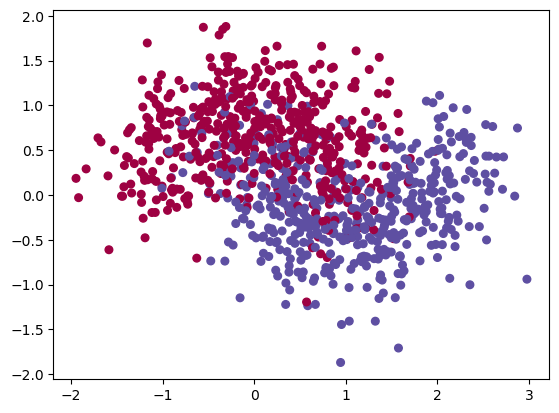

In [11]:
N=1000 # Total de datos
noisy_data = sklearn.datasets.make_moons(n_samples=N, noise=0.4, random_state=17) # Generamos datos con ruido
X,Y = noisy_data # Separamos los datos de entrada y salida

plt.scatter(X[:,0], X[:,1], c=Y, s=30, cmap=plt.cm.Spectral) # Graficamos los datos
plt.show()

In [12]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=.4, shuffle=True, random_state=17)

mimodelo = RandomForestClassifier()

clf = mimodelo.fit(Xtrain,Ytrain)

results = clf.predict(Xtest)

confusion_matrix(Ytest, results)

array([[165,  37],
       [ 32, 166]])

In [13]:
clf.score(Xtest, Ytest)

0.8275

In [14]:
clf.feature_importances_

array([0.46085026, 0.53914974])

<BarContainer object of 2 artists>

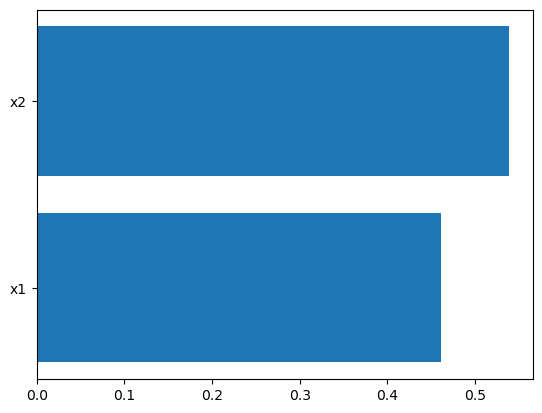

In [15]:
plt.barh(['x1','x2'], width=clf.feature_importances_)

In [16]:
## Algunos de lo hiperparámetros del clasificador bosque aleatorio:
mimodelo2 = RandomForestClassifier(n_estimators=10,  # número de árboles en el Forest y después promedia por votación.
                                   criterion='gini',   # métrica para determinar las ramas. También puede ser: 'entropy', para la GananciaDeInformación (IG).
                                   max_depth=2, # Depth=k : máximo 2^k líneas/ramas.        
                                   min_samples_split = 6,  # mínimo de puntos muestrales requeridos en un nodo para hacer la ramificación. Puede ser fracción de 0 a 1.
                                   min_samples_leaf = 4,  # mínimo de puntos muestrales que deben quedar en cada nueva ramificación (hojas). Puede ser fracción de 0 a 1.
                                   #max_features= 'auto',   # número de características (features) que se consideran en cada ramificación: auto=sqrt(n_features).
                                   max_leaf_nodes=16,  # solo nos quedamos con las mejores k hojas.
                                   bootstrap=True,  # Cada Árbol se muestrea seleccionando la cantidad de datos del conjunto de entrenamiento, pero con reemplazo. False:los datos usados en cada árbol simpre es el mismo, el Train-set.
                                   oob_score=True,  # en caso de utilizar Out-of-bag samples.
                                   verbose=0,     # tipo de despliega de información durante el entrenamiento.
                                   n_jobs=-1,    # total de hilos a usar en las rutinas paralelizables: "-1" :usar todos los posibles. 
                                   max_samples=None,   # Cuando se usa Boostrap, es el total de datos de Xtrain a usar en cada árbol. "None" usará Xtrain[0]. 
                                   random_state=19)

In [17]:
clf2 = mimodelo2.fit(Xtrain,Ytrain)
clf2.score(Xtest,Ytest)

c:\Users\quesa\.conda\envs\CursoCD\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


0.855